# Table II — BEM vs BEM+NN

Test-set RMSE (paper Table II format). Each model is evaluated once: `labels` are the BEM residual (→ **BEM** row), `labels - preds` is the residual after the NN (→ **BEM+NN** row). Paper rows are hardcoded.

**c1 / c2 / c3** = which aero params the CMA-ES run freed (all `--loss both`; see `CMAES-results/<ts>/coeff.txt`):

| row | CMA-ES run | freed params |
|---|---|---|
| BEM | — | none (defaults) |
| c1 | `2026-07-23-11-57-11` | 5: cl, cd, lift_offset, hforce_scale, thrust_scale |
| c2 | `2026-07-22-18-39-25` | all 19 |
| c3 | `2026-07-23-15-54-29` | 16: c2 minus lift_offset, hforce_scale, thrust_scale |

In [3]:
import os, sys, importlib.util
from pathlib import Path

import numpy as np
import pandas as pd

NBEM = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'processed_data').exists())
os.chdir(NBEM / 'code' / 'Python')

# analysis/utils.py shadows the code/Python/utils namespace package (no __init__.py),
# so drop any analysis dir from sys.path and evict the cached `utils` before importing.
analysis_dir = str(NBEM / 'analysis')
sys.path[:] = [p for p in sys.path if p != analysis_dir]
for m in [k for k in sys.modules if k == 'utils' or k.startswith('utils.')]:
    del sys.modules[m]

sys.path.insert(0, str(NBEM / 'code' / 'Python'))
from generate_ablation_study import run_inference  # uses code/Python/utils/*

# load metrics straight from its file (never via sys.path, to avoid the utils clash)
spec = importlib.util.spec_from_file_location('measure_bem_RMSE', str(NBEM / 'analysis' / 'measure_bem_RMSE.py'))
mbr = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mbr)
metrics = mbr.metrics

%matplotlib inline
# generate_ablation_study imports visualization.py which forces Agg; re-enable inline here

In [4]:
MODELS = {
    'BEM':    ('train_logs/20260708-223500', 'data/bem/test'),
    'BEM c1': ('train_logs/20260723-181423', 'data/2026-07-23-11-57-11/test'),
    'BEM c2': ('train_logs/20260724-140022', 'data/2026-07-22-18-39-25/test'),
    'BEM c3': ('train_logs/20260804-110251', 'data/2026-07-23-15-54-29/test'),
}

def row(res):
    fxy, fz, F = metrics(res[:, 0:3])
    mxy, mz, M = metrics(res[:, 3:6])
    return {'Fxy': fxy, 'Fz': fz, 'Mxy': mxy, 'Mz': mz, 'F': F, 'M': M}

rows = {}
for name, (lf, dr) in MODELS.items():
    preds, labels, _ = run_inference(lf, dr)
    rows[name] = row(labels)
    rows[name + '+NN'] = row(labels - preds)

#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 13 experiments.
Decoding data...


100%|██████████| 13/13 [00:01<00:00,  9.04it/s]


Highest angular speed observed in the dataset: 15.318 rad/s
Highest linear speed observed in the dataset: 17.724 m/s
Highest residual force observed in the dataset: 17.200 N
Highest residual torque observed in the dataset: 0.745 Nm
Found 1691 samples assembled from 215829 raw data points belonging to 13 experiments:


100%|██████████| 1691/1691 [00:15<00:00, 106.40it/s]


#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 13 experiments.
Decoding data...


...

100%|██████████| 1691/1691 [00:15<00:00, 110.11it/s]


#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 13 experiments.
Decoding data...


100%|██████████| 13/13 [00:01<00:00,  9.49it/s]


Highest angular speed observed in the dataset: 15.318 rad/s
Highest linear speed observed in the dataset: 17.724 m/s
Highest residual force observed in the dataset: 7.982 N
Highest residual torque observed in the dataset: 0.356 Nm
Found 1691 samples assembled from 215829 raw data points belonging to 13 experiments:


100%|██████████| 1691/1691 [00:15<00:00, 110.45it/s]


In [5]:
PAPER = {
    'paper BEM':    {'Fxy': 0.803, 'Fz': 1.265, 'Mxy': 0.090, 'Mz': 0.017, 'F': 0.982, 'M': 0.074},
    'paper BEM+NN': {'Fxy': 0.204, 'Fz': 0.504, 'Mxy': 0.014, 'Mz': 0.004, 'F': 0.335, 'M': 0.012},
}

COLS = ['Fxy', 'Fz', 'Mxy', 'Mz', 'F', 'M']
order = ['paper BEM','BEM', 'BEM c1', 'BEM c2', 'BEM c3', 'BEM+NN', 'BEM c1+NN', 'BEM c2+NN', 'BEM c3+NN', 'paper BEM+NN']
allrows = {**rows, **PAPER}
df = pd.DataFrame({k: {c: allrows[k][c] for c in COLS} for k in order}).T[COLS]
df.index.name = 'config'

base = df.loc['paper BEM+NN']
df['F impr%'] = (base['F'] - df['F']) / base['F'] * 100
df['M impr%'] = (base['M'] - df['M']) / base['M'] * 100
df = df[['Fxy', 'Fz', 'Mxy', 'Mz', 'F', 'F impr%', 'M', 'M impr%']]


def color_impr(col):
    return ['color: #2e7d32' if v > 0 else 'color: #c62828' if v < 0 else '' for v in col]


outline = {'border-left': '2px solid #444', 'border-right': '2px solid #444'}
(df.style
   .format({'Fxy': '{:.3f}', 'Fz': '{:.3f}', 'Mxy': '{:.3f}', 'Mz': '{:.3f}',
            'F': '{:.3f}', 'M': '{:.3f}', 'F impr%': '{:+.1f}%', 'M impr%': '{:+.1f}%'})
   .set_properties(subset=['F', 'M'], **outline)
   .apply(color_impr, subset=['F impr%', 'M impr%'])
   .set_caption('Test-set RMSE (Table II format) — impr% vs paper BEM+NN'))

,Fxy,Fz,Mxy,Mz,F,F impr%,M,M impr%
config,,,,,,,,
paper BEM,0.803,1.265,0.090,0.017,0.982,-193.1%,0.074,-516.7%
BEM,0.575,1.664,0.127,0.015,1.069,-219.2%,0.104,-769.5%
BEM c1,0.627,1.086,0.084,0.025,0.809,-141.6%,0.070,-482.2%
BEM c2,0.829,1.007,0.088,0.009,0.892,-166.4%,0.072,-503.2%
BEM c3,0.414,0.899,0.039,0.029,0.619,-84.9%,0.036,-201.7%
BEM+NN,0.193,0.547,0.009,0.002,0.353,-5.3%,0.008,+36.3%
BEM c1+NN,0.201,0.541,0.008,0.005,0.353,-5.3%,0.007,+39.5%
BEM c2+NN,0.201,0.375,0.007,0.002,0.272,+18.9%,0.006,+54.0%
BEM c3+NN,0.186,0.430,0.004,0.003,0.291,+13.1%,0.004,+67.7%


In [8]:
import glob

SEG_KEY = 'BEM c3'  # which model's BEM+NN to plot ('BEM', 'BEM c1', 'BEM c2')
lf, test_dir = MODELS[SEG_KEY]
LABELS = ['fx', 'fy', 'fz', 'tx', 'ty', 'tz']

seg = {}
for f in sorted(glob.glob(os.path.join(test_dir, '*.csv'))):
    preds, labels, infos = run_inference(lf, f)
    sid = os.path.basename(f).split('_', 1)[1][:-4]
    t = infos[:, 0]
    meas = labels + infos[:, 2:8]
    model = preds + infos[:, 2:8]
    fr, tr = meas[:, :3] - model[:, :3], meas[:, 3:] - model[:, 3:]
    seg[sid] = dict(t=t, meas=meas, pred=model,
                    frmse=np.sqrt((fr ** 2).sum(1).mean()),
                    trmse=np.sqrt((tr ** 2).sum(1).mean()))

sids = list(seg)
best_f = min(sids, key=lambda s: seg[s]['frmse']);  worst_f = max(sids, key=lambda s: seg[s]['frmse'])
best_t = min(sids, key=lambda s: seg[s]['trmse']);  worst_t = max(sids, key=lambda s: seg[s]['trmse'])

#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 1 experiments.
Decoding data...


100%|██████████| 1/1 [00:00<00:00,  8.98it/s]

Highest angular speed observed in the dataset: 2.764 rad/s
Highest linear speed observed in the dataset: 9.693 m/s
Highest residual force observed in the dataset: 2.919 N
Highest residual torque observed in the dataset: 0.138 Nm
Found 132 samples assembled from 16797 raw data points belonging to 1 experiments:



100%|██████████| 132/132 [00:01<00:00, 86.65it/s] 


#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 1 experiments.
Decoding data...


...

100%|██████████| 331/331 [00:03<00:00, 88.47it/s] 


#############################
False
------------------------------------------
Building Validation Dataset
------------------------------------------
Dataset contains 1 experiments.
Decoding data...


100%|██████████| 1/1 [00:00<00:00,  8.42it/s]


Highest angular speed observed in the dataset: 3.508 rad/s
Highest linear speed observed in the dataset: 16.537 m/s
Highest residual force observed in the dataset: 4.662 N
Highest residual torque observed in the dataset: 0.247 Nm
Found 132 samples assembled from 16909 raw data points belonging to 1 experiments:


100%|██████████| 132/132 [00:01<00:00, 87.50it/s]


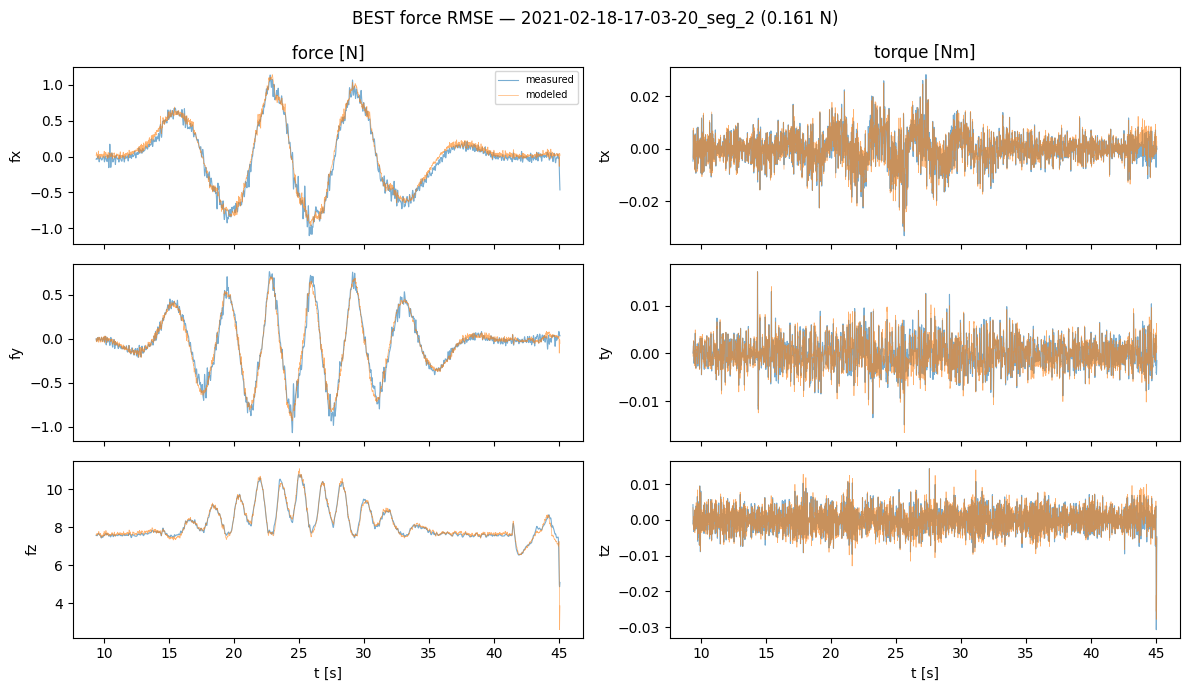

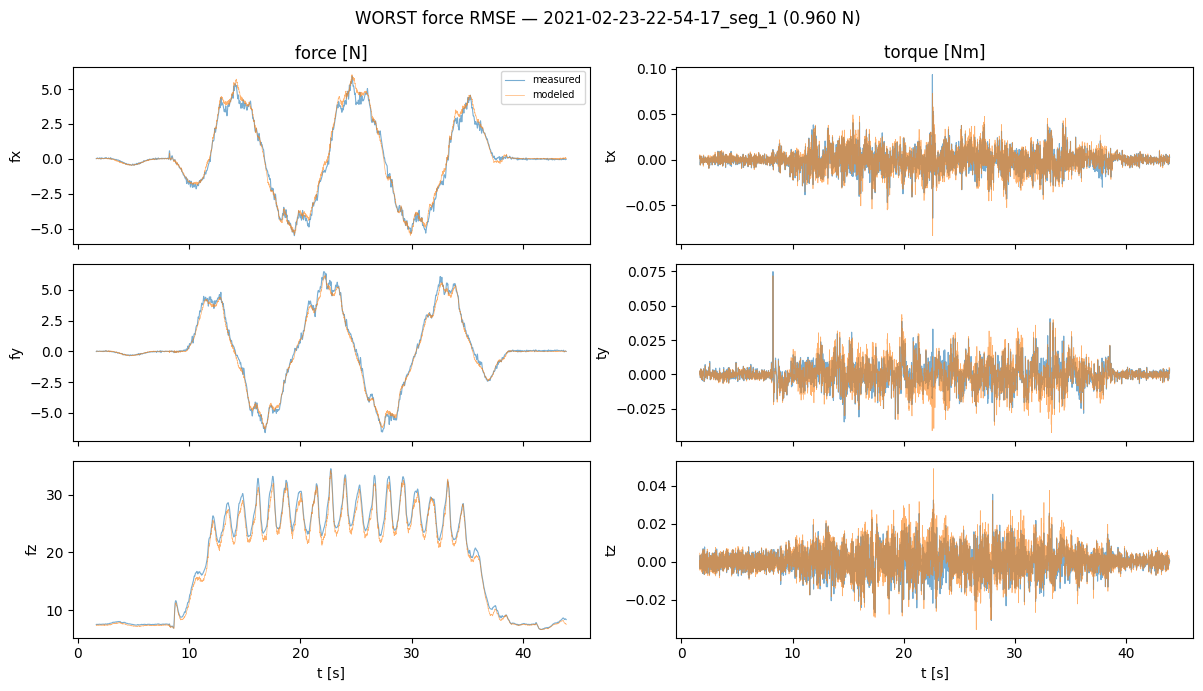

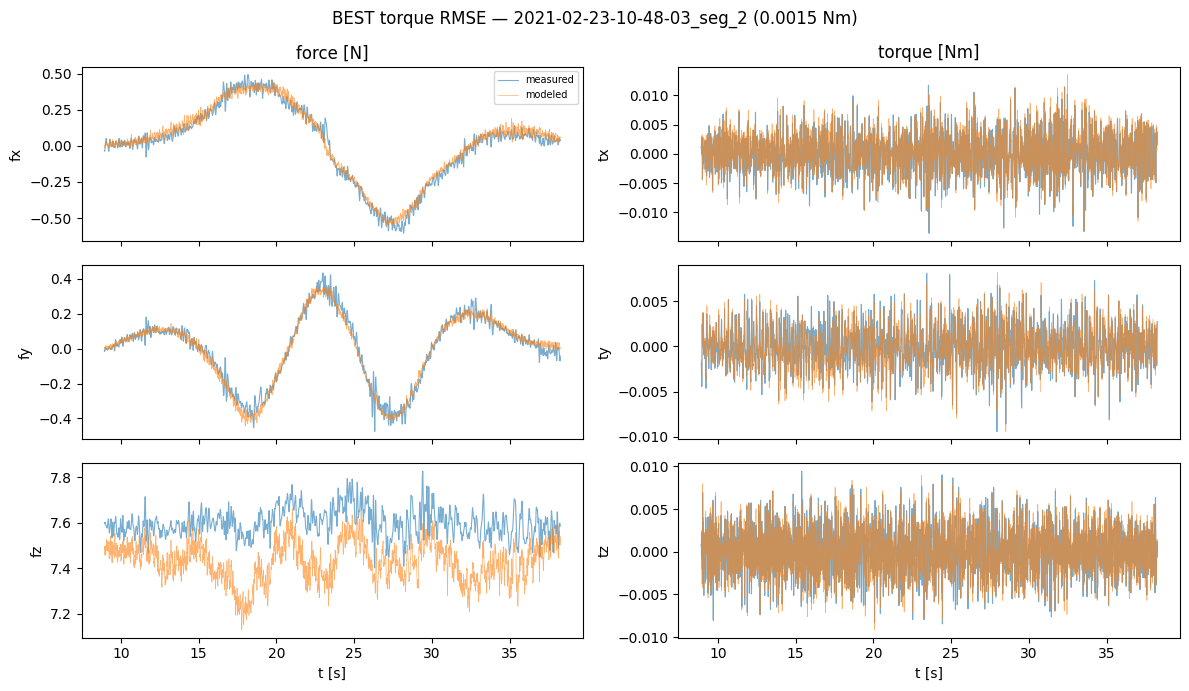

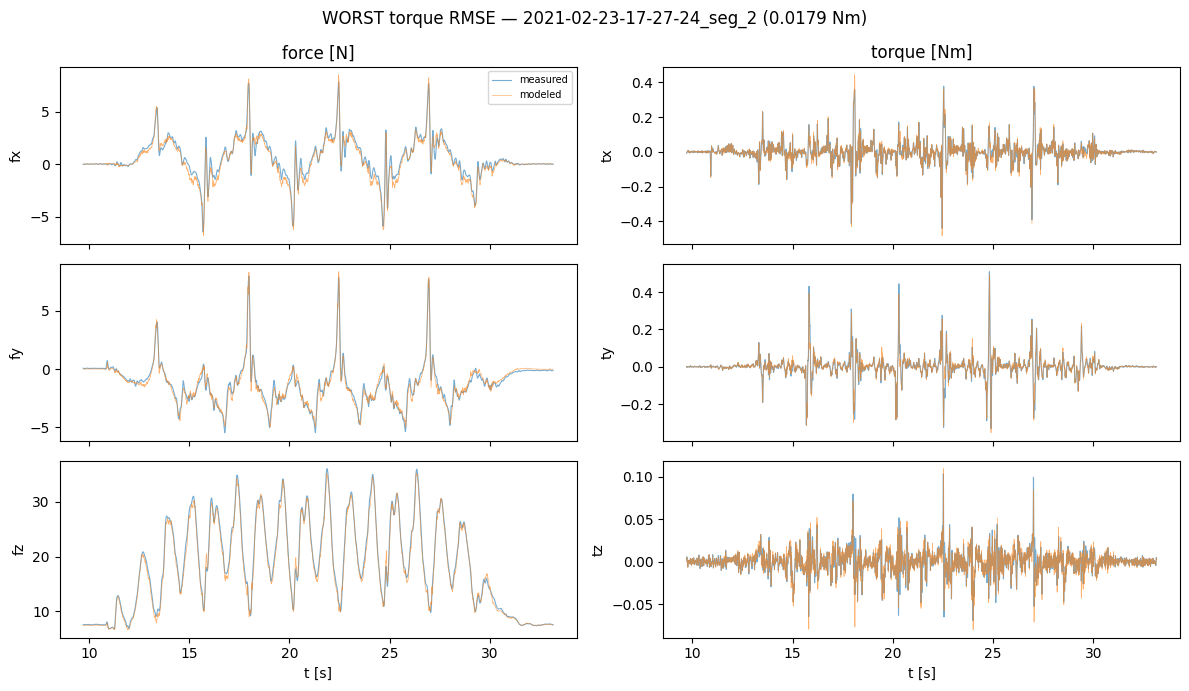

In [9]:
import matplotlib.pyplot as plt


def plot_seg(sid, title):
    s = seg[sid]
    fig, ax = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
    for i, c in enumerate(LABELS):
        a = ax[i % 3, i // 3]
        a.plot(s["t"], s["meas"][:, i], lw=0.8, alpha=0.6, label="measured")
        a.plot(s["t"], s["pred"][:, i], lw=0.5, alpha=0.6 ,label="modeled")
        a.set_ylabel(c)
    ax[0, 0].set_title("force [N]"); ax[0, 1].set_title("torque [Nm]")
    ax[2, 0].set_xlabel("t [s]"); ax[2, 1].set_xlabel("t [s]")
    ax[0, 0].legend(loc="upper right", fontsize=7)
    fig.suptitle(title); fig.tight_layout()


plot_seg(best_f,  f"BEST force RMSE — {best_f} ({seg[best_f]['frmse']:.3f} N)")
plot_seg(worst_f, f"WORST force RMSE — {worst_f} ({seg[worst_f]['frmse']:.3f} N)")
plot_seg(best_t,  f"BEST torque RMSE — {best_t} ({seg[best_t]['trmse']:.4f} Nm)")
plot_seg(worst_t, f"WORST torque RMSE — {worst_t} ({seg[worst_t]['trmse']:.4f} Nm)")